In [1]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

## functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Plot spike init data

In [32]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/multielec_thr_bielec2_dense/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_y30_threshold/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig3_y0/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/somatic_y20_dend/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig4_rot45/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/planar/fig4_perp_v2/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig3_y0_TEST/005Dt/'
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig3_rot45_TEST/005Dt/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1][:-9]),2)
        # if curr1 < -1 and curr1 > -1.5 and curr2 > -0.8:
        if curr1 < 7 and curr1 > -7 and curr2 < 7 and curr2 > -7:
            i1.append(round(float(file.split('_')[0]),2))
            i2.append(round(float(file.split('_')[1][:-9]),2))
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-1025.61 10.61 42]
 [-1004.39 -10.61 42]]


In [162]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/multielec_thr_bielec1_dense/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_y0/005Dt/'
dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_y10_threshold/005Dt/'


# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1][:-9]),2)
        # if curr1 < 1.65 and curr1 > -1.52:
        # if np.abs(curr1) < 5 and np.abs(curr2) < 5:
        # Exclude some bad data in the center
        if np.abs(curr1) < 0.6 and np.abs(curr2) < 0.6:
            continue
        else:
            i1.append(round(float(file.split('_')[0]),3))
            i2.append(round(float(file.split('_')[1][:-9]),3))
            spikes.append(data[0])
            init_segs.append(data[1])

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig3_y10_threshold/005Dt/electrodes.pkl.pbz2'

In [33]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]

In [34]:
# Make list of unique segments, these are the bins
bins = np.unique(init_segs_unroll)
print('List of unique segs:\n', bins)

List of unique segs:
 [159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176
 177 178]


In [35]:
# make an empty list of zeros of same length as bins
counts = np.zeros(len(bins))
print(counts)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [36]:
# Also calculate center of mass 
COM = []

# march through init_segs, adjusting spike count normalized by number of spiking segs
counts = np.zeros(len(bins))
for lst in init_segs:
    # If spiking
    if len(lst) > 0:
        COM.append(np.mean(lst))
        normalized_spike = 1/len(lst)
        for seg in lst:
           # Find index of seg in bins and normalized_spike to same counts idx 
           idx = np.argwhere(bins == seg)[0][0]
           counts[idx] += normalized_spike
    else:
        COM.append(300)


In [37]:
print(len(i1))
print(len(COM))
print(COM)

200
200
[170.0, 167.5, 170.5, 171.0, 170.5, 167.0, 171.5, 167.0, 171.0, 167.0, 167.5, 170.0, 170.5, 168.5, 166.0, 170.5, 171.0, 166.5, 167.0, 166.5, 171.0, 168.0, 168.5, 169.0, 166.5, 169.5, 167.0, 168.0, 171.0, 171.5, 170.5, 171.0, 171.0, 172.0, 170.0, 171.5, 167.5, 170.5, 166.5, 170.5, 169.0, 167.0, 169.5, 168.5, 167.0, 168.0, 167.0, 167.0, 166.5, 169.0, 167.0, 171.0, 169.5, 169.0, 168.0, 170.5, 171.0, 167.5, 166.5, 171.0, 169.0, 167.0, 171.5, 168.0, 167.0, 169.5, 170.0, 169.0, 171.0, 169.5, 172.0, 168.0, 168.5, 168.5, 167.0, 168.5, 169.5, 167.5, 169.0, 167.0, 169.0, 171.5, 166.5, 167.5, 167.0, 169.5, 168.5, 170.0, 166.5, 166.0, 171.0, 170.5, 170.0, 167.0, 166.5, 167.0, 169.5, 167.0, 166.5, 166.5, 167.5, 171.0, 167.0, 167.5, 168.5, 166.5, 165.5, 172.0, 166.5, 167.5, 168.5, 171.0, 168.5, 167.5, 171.0, 167.0, 171.5, 170.5, 170.5, 169.0, 170.0, 167.5, 167.5, 167.5, 167.5, 170.0, 170.5, 166.5, 169.0, 169.0, 166.5, 171.0, 170.5, 167.0, 166.5, 170.0, 170.0, 168.0, 169.5, 172.0, 168.0, 170.

In [38]:
np.min(COM)

165.5

In [39]:
print(len(bins))
print(len(COM))
print(len(counts))

20
200
20


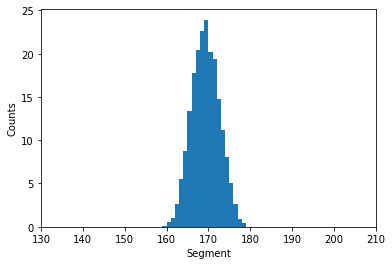

In [40]:
# Plot the histogram from pre-counted data
plt.bar(bins, counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Counts')
plt.xlim([130,210])
# plt.xlim([140,200])

# Show the plot
plt.show()

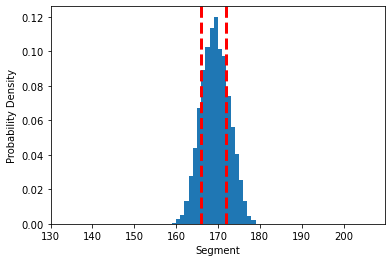

In [41]:
total_counts = sum(counts)
# total_counts = 2412.0
bin_width = bins[1] - bins[0]
normalized_counts = [count / (total_counts * bin_width) for count in counts]
# Plot the normalized histogram from pre-counted data
plt.bar(bins, normalized_counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Probability Density')
plt.xlim([130, 210])
# plt.xlim([140, 200])
# plt.ylim([0,0.19])
# plot xticks every 1
plt.xticks(np.arange(130, 210, 10))
# plt.yticks(np.arange(0, 0.19, 0.02))
plt.axvline(172, color='r', linewidth=3, linestyle='--')
plt.axvline(166, color='r', linewidth=3, linestyle='--')
# plt.xticks(np.arange(140, 200, 1))
# plt.savefig("figure4_A_triphasic_hist.pdf",format="pdf", bbox_inches="tight")
plt.show()

In [42]:
print(total_counts)

198.99999999999983


In [43]:
# Try rounding ceiling function on COM
COM_round = [np.ceil(com) for com in COM]
print(COM_round)

[170.0, 168.0, 171.0, 171.0, 171.0, 167.0, 172.0, 167.0, 171.0, 167.0, 168.0, 170.0, 171.0, 169.0, 166.0, 171.0, 171.0, 167.0, 167.0, 167.0, 171.0, 168.0, 169.0, 169.0, 167.0, 170.0, 167.0, 168.0, 171.0, 172.0, 171.0, 171.0, 171.0, 172.0, 170.0, 172.0, 168.0, 171.0, 167.0, 171.0, 169.0, 167.0, 170.0, 169.0, 167.0, 168.0, 167.0, 167.0, 167.0, 169.0, 167.0, 171.0, 170.0, 169.0, 168.0, 171.0, 171.0, 168.0, 167.0, 171.0, 169.0, 167.0, 172.0, 168.0, 167.0, 170.0, 170.0, 169.0, 171.0, 170.0, 172.0, 168.0, 169.0, 169.0, 167.0, 169.0, 170.0, 168.0, 169.0, 167.0, 169.0, 172.0, 167.0, 168.0, 167.0, 170.0, 169.0, 170.0, 167.0, 166.0, 171.0, 171.0, 170.0, 167.0, 167.0, 167.0, 170.0, 167.0, 167.0, 167.0, 168.0, 171.0, 167.0, 168.0, 169.0, 167.0, 166.0, 172.0, 167.0, 168.0, 169.0, 171.0, 169.0, 168.0, 171.0, 167.0, 172.0, 171.0, 171.0, 169.0, 170.0, 168.0, 168.0, 168.0, 168.0, 170.0, 171.0, 167.0, 169.0, 169.0, 167.0, 171.0, 171.0, 167.0, 167.0, 170.0, 170.0, 168.0, 170.0, 172.0, 168.0, 171.0, 167.0

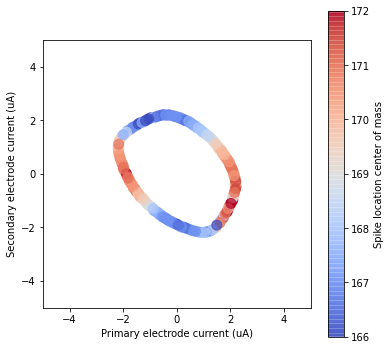

In [44]:
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
# color_map = ['black' if x == 0 else 'red' for x in spikes] 

# # fix the polarity to match jepson figure
# i1_fix = [-x for x in i1]
# i2_fix = [-x for x in i2]

# Define the colormap
# cmap = plt.cm.get_cmap('RdBu')
cmap = plt.cm.get_cmap('coolwarm')

vmin = 166
vmax = 172
# vmin = 165
# vmax = 173

# # -------
# # Define the colormap and custom outlier color
# cmap = plt.cm.RdBu
# custom_outlier_color = 'cyan'

# # Create a custom colormap with an appended outlier color
# new_cmap = mcolors.ListedColormap(cmap(np.linspace(0, 1, cmap.N)))
# new_cmap = new_cmap(np.linspace(0, 1, cmap.N))
# new_cmap = np.vstack((new_cmap, mcolors.to_rgba(custom_outlier_color)))
# custom_cmap = mcolors.ListedColormap(new_cmap)

# # Define the norm with boundaries to include the outlier
# # vmin = 156
# # vmax = 182
# vmin = 165
# vmax = 173
# bounds = np.linspace(vmin, vmax, cmap.N)
# bounds = np.append(bounds, [vmax + 10])  # Add an extra boundary for the outlier color
# norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)
# # -------


# ax.scatter(i1,i2,c=color_map,s=50,alpha=0.5)
# sc = ax.scatter(i1_fix,i2_fix,c=COM,cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=0.5)
sc = ax.scatter(i1,i2,c=COM,cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=0.7)
# sc = ax.scatter(i1,i2,c=COM,cmap=custom_cmap,vmin=vmin,vmax=vmax,s=100,alpha=1)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
# ax.set_xlim(-7,7)
# ax.set_ylim(-7,7)
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)


cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Spike location center of mass')

# ax.set_ylim(0,4.5)
# ax.set_ylim(0,np.max(i2_fix)+0.5)
# ax.set_ylim(-2,2)
## remove y axis labels
# ax.set_yticklabels([])
# ax.set_title('Multielec tradeoff \n (axon aligned at y=0um)\n distal axon, straddling')
# plt.savefig("figure4_perp_colored.pdf",format="pdf", bbox_inches="tight")
# ax.set_title('Single electrode stimulation, aligned electrode 12um away\n red = spike; blue = spike at lobes; black = no spike')

In [45]:
print(COM)

[170.0, 167.5, 170.5, 171.0, 170.5, 167.0, 171.5, 167.0, 171.0, 167.0, 167.5, 170.0, 170.5, 168.5, 166.0, 170.5, 171.0, 166.5, 167.0, 166.5, 171.0, 168.0, 168.5, 169.0, 166.5, 169.5, 167.0, 168.0, 171.0, 171.5, 170.5, 171.0, 171.0, 172.0, 170.0, 171.5, 167.5, 170.5, 166.5, 170.5, 169.0, 167.0, 169.5, 168.5, 167.0, 168.0, 167.0, 167.0, 166.5, 169.0, 167.0, 171.0, 169.5, 169.0, 168.0, 170.5, 171.0, 167.5, 166.5, 171.0, 169.0, 167.0, 171.5, 168.0, 167.0, 169.5, 170.0, 169.0, 171.0, 169.5, 172.0, 168.0, 168.5, 168.5, 167.0, 168.5, 169.5, 167.5, 169.0, 167.0, 169.0, 171.5, 166.5, 167.5, 167.0, 169.5, 168.5, 170.0, 166.5, 166.0, 171.0, 170.5, 170.0, 167.0, 166.5, 167.0, 169.5, 167.0, 166.5, 166.5, 167.5, 171.0, 167.0, 167.5, 168.5, 166.5, 165.5, 172.0, 166.5, 167.5, 168.5, 171.0, 168.5, 167.5, 171.0, 167.0, 171.5, 170.5, 170.5, 169.0, 170.0, 167.5, 167.5, 167.5, 167.5, 170.0, 170.5, 166.5, 169.0, 169.0, 166.5, 171.0, 170.5, 167.0, 166.5, 170.0, 170.0, 168.0, 169.5, 172.0, 168.0, 170.5, 167.0

([<matplotlib.axis.XTick at 0x7f7410644438>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

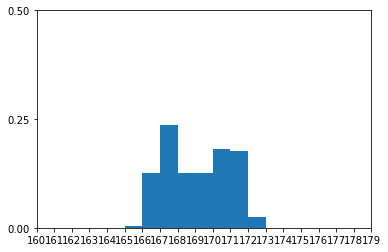

In [46]:
## Plot histogram of just the at threshold points
bins_threshold = np.arange(166-3,173+3,1)
plt.hist(COM,bins_threshold, density=True)
# plt.ylim([0,1.1])
plt.ylim([0,0.5])
# plt.yticks([0,0.50,1])
plt.yticks([0,0.25,0.50])
plt.xticks(np.arange(160, 180, 1))
# plt.savefig("figure4_perp_colored_hist.pdf",format="pdf", bbox_inches="tight")

In [193]:
import random
import math
import numpy as np

In [194]:
## Let's try to do some type of density sampling to make it 
##  roughly one sample per some unit arc length. This will help 
##  normalize the data for the histogram

# Set random seed
random.seed(17) # 10

# Create a vector representing the (x,y) location of all the data points
data = np.array([i1,i2,COM]).T
print(data.shape)

# For a given point, find how many points fall within a 0.05 radius
#  of that point. If the number of points is greater than 1, then
#  randomly sample one of the points, and remove the others from data
#  until we have a roughly uniform distribution of points
#  (i.e. one point per 0.05 radius)
try: 
    for i in range(200):
        dists = np.linalg.norm(data - data[i], axis=1)
        idx = np.where(dists < 0.02)[0]
        len_remove = idx.shape[0]
        # If there are more than 1 point in the radius, randomly sample
        #  one of the points and remove the rest
        print(data.shape)
        while len_remove > 1:
            idx_remove = random.choice(idx)
            data = np.delete(data, idx_remove, axis=0)
            len_remove -= 1
except:
    print('Ran to the end of the data')

print(data.shape)


(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
(74, 3)
Ran to the end of the data
(74, 3)


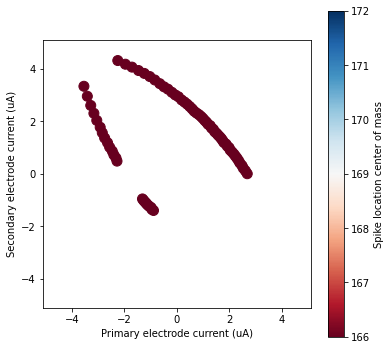

In [195]:
# # extract i1 and i2 from data
# i1_filtered = data[:,0]
# i2_filtered = data[:,1]
# i2_filtered = data[:,2]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# # Create color_map from spikes where spikes=1 is red and spikes=0 is black
# color_map = ['black' if x == 0 else 'red' for x in spikes] 

# # fix the polarity to match jepson figure
# i1_fix = [-x for x in i1]
# i2_fix = [-x for x in i2]

# Define the colormap
cmap = plt.cm.get_cmap('RdBu')
# cmap = plt.cm.get_cmap('brg')

vmin = 166
vmax = 172

# # -------
# # Define the colormap and custom outlier color
# cmap = plt.cm.RdBu
# custom_outlier_color = 'cyan'

# # Create a custom colormap with an appended outlier color
# new_cmap = mcolors.ListedColormap(cmap(np.linspace(0, 1, cmap.N)))
# new_cmap = new_cmap(np.linspace(0, 1, cmap.N))
# new_cmap = np.vstack((new_cmap, mcolors.to_rgba(custom_outlier_color)))
# custom_cmap = mcolors.ListedColormap(new_cmap)

# # Define the norm with boundaries to include the outlier
# # vmin = 156
# # vmax = 182
# vmin = 165
# vmax = 173
# bounds = np.linspace(vmin, vmax, cmap.N)
# bounds = np.append(bounds, [vmax + 10])  # Add an extra boundary for the outlier color
# norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)
# # -------


# ax.scatter(i1,i2,c=color_map,s=50,alpha=0.5)
# sc = ax.scatter(i1_fix,i2_fix,c=COM,cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=0.5)
sc = ax.scatter(data[:,0],data[:,1],c=data[:,2],cmap=cmap,vmin=vmin,vmax=vmax,s=100,alpha=1)
# sc = ax.scatter(i1,i2,c=COM,cmap=custom_cmap,vmin=vmin,vmax=vmax,s=100,alpha=1)

ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
ax.set_xlim(-5.1,5.1)
ax.set_ylim(-5.1,5.1)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Spike location center of mass')


(array([0.        , 0.        , 0.        , 0.01639344, 0.03278689,
        0.04918033, 0.13114754, 0.27868852, 0.19672131, 0.31147541,
        0.21311475, 0.14754098, 0.14754098, 0.18032787, 0.14754098,
        0.1147541 , 0.01639344, 0.        , 0.        , 0.01639344,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([163. , 163.5, 164. , 164.5, 165. , 165.5, 166. , 166.5, 167. ,
        167.5, 168. , 168.5, 169. , 169.5, 170. , 170.5, 171. , 171.5,
        172. , 172.5, 173. , 173.5, 174. , 174.5, 175. , 175.5]),
 <BarContainer object of 25 artists>)

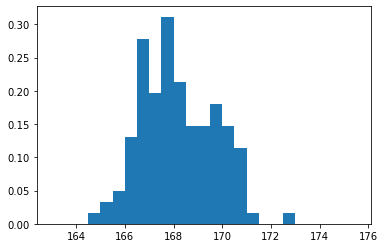

In [38]:
## Plot histogram of just the at threshold points
bins_threshold = np.arange(166-3,173+3,0.5)
plt.hist(data[:,2],bins_threshold, density=True)

In [21]:
print(i1)
print(i2)

[3.3, 7.2, -6.5, -5.0, 4.58, -2.8, 6.9, -7.22, -3.93, -5.21, -4.6, -5.94, -4.4, 4.35, -4.7, -6.12, 6.0, -5.7, -6.31, -4.2, -5.67, 4.28, -3.4, -6.86, -1.8, -3.87, 3.15, 7.35, -5.48, 5.17, -1.9, 5.78, 5.62, 6.53, 4.65, -6.22, -4.11, -4.84, -7.32, 3.38, 3.9, -7.0, -4.5, 5.25, 4.72, -6.0, -6.95, 4.2, -5.6, -4.29, -3.25, -1.6, 6.97, 7.42, 4.42, 5.03, -3.7, 7.05, -2.3, -4.57, 4.12, -5.8, -5.85, 6.82, -5.1, -6.7, -5.76, 5.4, -1.5, 5.7, -5.5, -5.3, -6.58, -6.1, -4.66, -3.93, 3.23, 3.6, -5.39, -4.0, 3.0, 4.5, -4.0, 3.45, -6.2, -5.9, -6.4, 6.67, 4.95, -6.03, -4.3, 3.08, 5.47, -3.1, -3.8, -1.7, 5.1, -4.38, -2.1, 7.12, 6.6, 6.75, -6.49, 3.67, 5.32, 4.8, -6.6, -4.93, 3.52, -2.95, -4.9, -2.5, -5.4, 6.07, 4.88, -5.3, 6.22, -6.67, -5.03, 4.05, -3.55, 6.15, -2.4, 3.83, 5.55, -3.83, 6.38, -2.2, -4.2, -6.9, 3.75, -6.8, -3.9, -4.47, -2.65, 7.27, -5.58, -3.73, -4.1, -7.13, -4.02, 5.85, -3.74, -3.85, -4.75, -6.3, -7.04, -5.2, -2.0, -6.77, -5.12, -3.85, 6.45, 6.3, 5.92, -7.41, 3.98, -4.8]
[7.68, 3.89, -3.6, 

## Fit linear curve to the data, forcing it to go through (0,thr) point

In [564]:
# Find the value of i2 when i1 is 0
i2_zero = i2_fix[i1_fix.index(0)]
print(i2_zero)

1.49


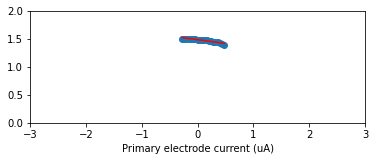

In [565]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Sample scatter data
x_data = i1_fix
y_data = i2_fix

# Define the point through which the line should pass
x0, y0 = 0, i2_zero

# Define the linear function that goes through (x0, y0)
def linear_func(x, a):
    return a * (x - x0) + y0

# Fit the data
params, _ = curve_fit(linear_func, x_data, y_data)

# Extract the slope
a = params[0]

# Generate the fitted line
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = linear_func(x_fit, a)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# Plot the data and the fitted line
ax.scatter(x_data, y_data, label='Data')
ax.plot(x_fit, y_fit, label=f'Fitted line: y = {a:.2f}(x - {x0}) + {y0}', color='red')
ax.set_aspect('equal')
ax.set_xlabel('Primary electrode current (uA)')
ax.set_xlim(-3,3)
ax.set_ylim(0,np.max(i2_fix)+0.5)
plt.show()

## Calculate nonlinearity index

In [258]:
N = len(i1_fix)
R = (np.max(i1_fix) - np.min(i1_fix))**2 + \
        (np.max(i2_fix) - np.min(i2_fix))**2

sq_distance = 0
for idx,curr in enumerate(i1_fix):
    fit = a * (curr - x0) + y0
    data = i2_fix[idx]
    sq_distance += (fit - data)**2

nonlinearity = (sq_distance)/(N*R)
print('R',R)
print('nonlinearity',nonlinearity)
print(np.log(nonlinearity))

R 17.582500000000003
nonlinearity 1.1897579365231683e-06
-13.641760686218822
